Question?
Do the strongest sensor relationships identified during the sensor analysis remain consistent within individual engines?
Objective
Validate Sensors 4,7,11,12 and 15 by examining their behaviours across individual sensors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
column_names=["engine_id","cycle"]+[f"setting_{i}" for i in range(1,4)]+[f"sensor_{i}" for i in range(1,22)]

df=pd.read_csv('../data/raw/train_FD001.txt',sep=r'\s+',header=None)

df.columns=column_names

df["max_cycle"]=df.groupby("engine_id")["cycle"].transform("max")
df["life_percent"]= (df["cycle"]/df["max_cycle"])*100

key_sensors=['sensor_4','sensor_7','sensor_11','sensor_12','sensor_15']

In [3]:
selected_engines=[1,33,44,55,66]

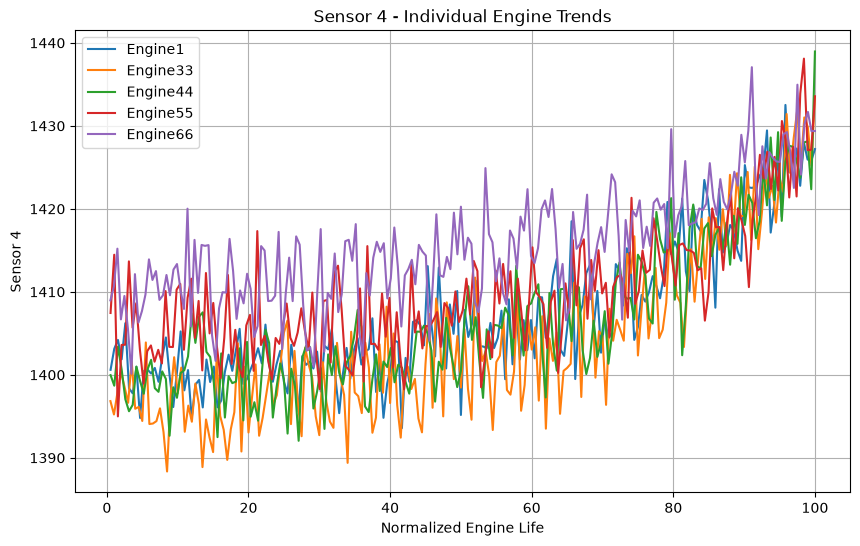

In [4]:
plt.figure(figsize=(10,6))

for engine in selected_engines:
    engine_data=df[df["engine_id"]==engine]

    plt.plot(engine_data["life_percent"],engine_data['sensor_4'],label=f"Engine{engine}")
    
plt.title("Sensor 4 - Individual Engine Trends")
plt.xlabel('Normalized Engine Life')
plt.ylabel('Sensor 4')
plt.legend()
plt.grid()

plt.show()

Sensor 4 fluctuates around a relatively stable average value during the early stages of normalized engine life. Although the sensor exhibits short-term increases and decreases, its overall values remain within a relatively consistent range. At approximately 60% normalized engine life, the sensor begins to show a noticeable upward trend that continues toward the end of the engine’s life.

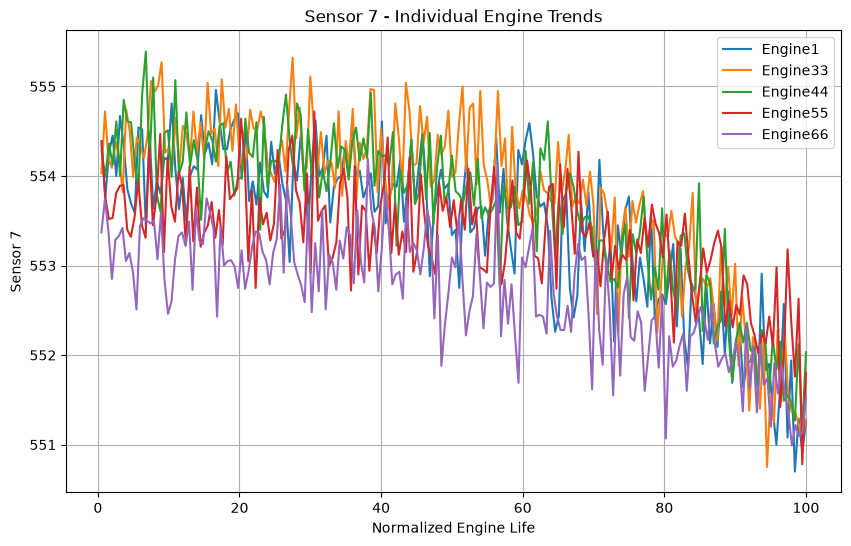

In [5]:
plt.figure(figsize=(10,6))

for engine in selected_engines:
    engine_data=df[df["engine_id"]==engine]

    plt.plot(engine_data["life_percent"],engine_data['sensor_7'],label=f"Engine{engine}")
    
plt.title("Sensor 7 - Individual Engine Trends")
plt.xlabel('Normalized Engine Life')
plt.ylabel('Sensor 7')
plt.legend()
plt.grid()

plt.show()

Sensor 7 fluctuates around a relatively stable average value during the early stages of normalized engine life. Despite short-term increases and decreases, the sensor remains within a relatively consistent range. At approximately 60% normalized engine life, the sensor begins to exhibit a noticeable downward trend that continues toward the end of the engine’s life.

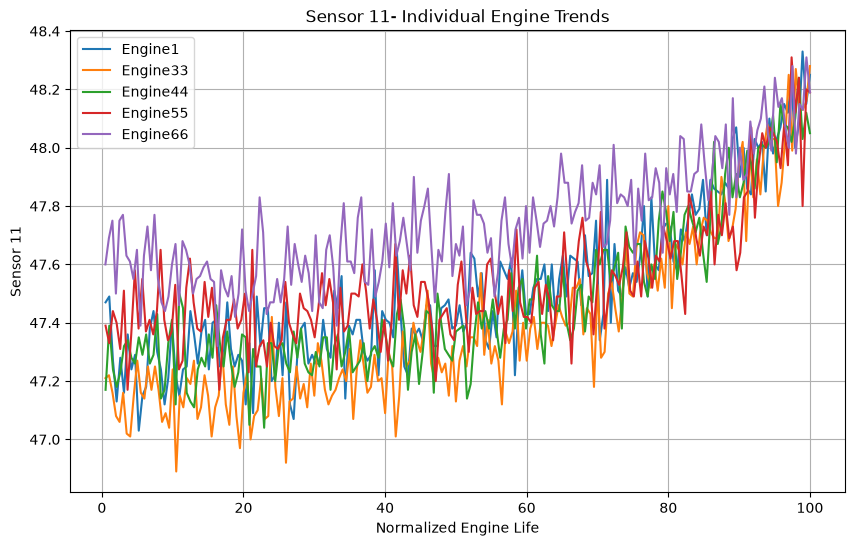

In [6]:
plt.figure(figsize=(10,6))

for engine in selected_engines:
    engine_data=df[df["engine_id"]==engine]

    plt.plot(engine_data["life_percent"],engine_data['sensor_11'],label=f"Engine{engine}")
    
plt.title("Sensor 11- Individual Engine Trends")
plt.xlabel('Normalized Engine Life')
plt.ylabel('Sensor 11')
plt.legend()
plt.grid()

plt.show()

Sensor 11 fluctuates around a relatively stable average value during the early stages of normalized engine life. While short-term increases and decreases are observed, the sensor remains within a relatively consistent range. At approximately 60% normalized engine life, Sensor 11 begins to show a noticeable upward trend toward the end of the engine’s life.

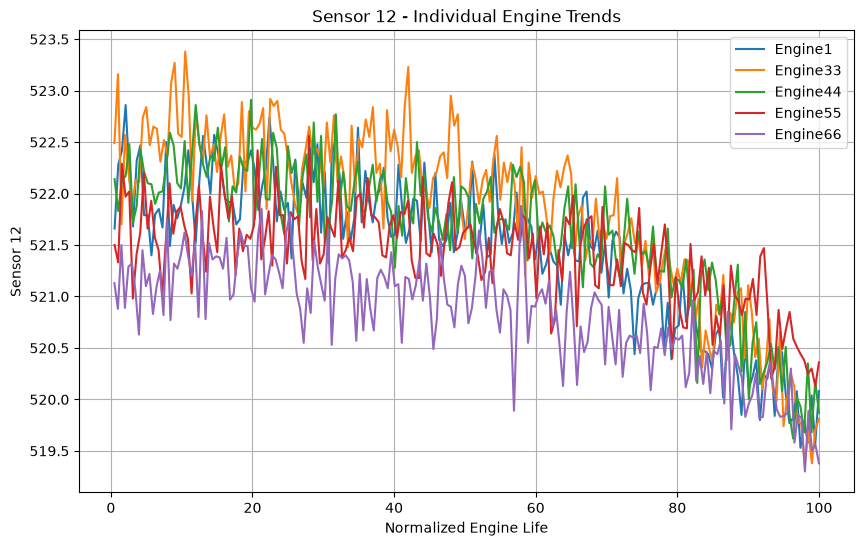

In [7]:
plt.figure(figsize=(10,6))

for engine in selected_engines:
    engine_data=df[df["engine_id"]==engine]

    plt.plot(engine_data["life_percent"],engine_data['sensor_12'],label=f"Engine{engine}")
    
plt.title("Sensor 12 - Individual Engine Trends")
plt.xlabel('Normalized Engine Life')
plt.ylabel('Sensor 12')
plt.legend()
plt.grid()

plt.show()

Sensor 12 fluctuates around a relatively stable average value during the early stages of normalized engine life. Although short-term fluctuations are present, the sensor remains within a relatively consistent range. At approximately 60% normalized engine life, Sensor 12 begins to exhibit a noticeable downward trend that continues toward the end of the engine’s life.

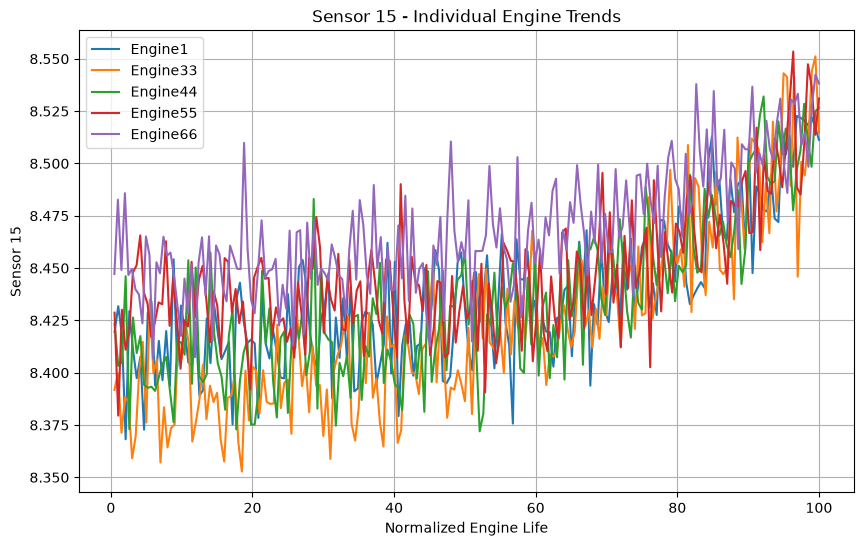

In [8]:
plt.figure(figsize=(10,6))

for engine in selected_engines:
    engine_data=df[df["engine_id"]==engine]

    plt.plot(engine_data["life_percent"],engine_data['sensor_15'],label=f"Engine{engine}")
    
plt.title("Sensor 15 - Individual Engine Trends")
plt.xlabel('Normalized Engine Life')
plt.ylabel('Sensor 15')
plt.legend()
plt.grid()

plt.show()

Sensor 15 fluctuates around a relatively stable average value during the early stages of normalized engine life. Despite short-term increases and decreases, its values remain within a relatively consistent range. At approximately 60% normalized engine life, Sensor 15 begins to show a noticeable upward trend toward the end of the engine’s life.

In [9]:
def calculate_engine_correlations(sensor):
    results=[]
    for engine,engine_data in df.groupby('engine_id'):
        correlation= engine_data['life_percent'].corr(engine_data[sensor])
        
        results.append({'engine_id':engine,'correlation': correlation})

    return pd.DataFrame(results)

calculate_engine_correlations('sensor_4').head()

,engine_id,correlation
0,1,0.824079
1,2,0.830417
2,3,0.789526
3,4,0.691810
4,5,0.836064


In [10]:
validation_results=[]
key_sensors=[f'sensor_{i}'for i in [4,7,11,12,15]]

for sensor in key_sensors:
    results= calculate_engine_correlations(sensor)
    mean_corr=results['correlation'].mean()
    
    if sensor in ['sensor_7','sensor_12']:
        expected_direction=(results['correlation']< 0).mean()*100
    else:
        expected_direction=(results['correlation']> 0).mean()*100
    
    validation_results.append({"Sensor":sensor,"Mean Within-Engine Correlation":mean_corr,"Percent Engines With Expected Direction":expected_direction})
    

validation_table=pd.DataFrame(validation_results)
validation_table

,Sensor,Mean Within-Engine Correlation,Percent Engines With Expected Direction
0,sensor_4,0.781614,100.0
1,sensor_7,-0.761514,100.0
2,sensor_11,0.810601,100.0
3,sensor_12,-0.789662,100.0
4,sensor_15,0.724844,100.0


In [11]:
validation_table

,Sensor,Mean Within-Engine Correlation,Percent Engines With Expected Direction
0,sensor_4,0.781614,100.0
1,sensor_7,-0.761514,100.0
2,sensor_11,0.810601,100.0
3,sensor_12,-0.789662,100.0
4,sensor_15,0.724844,100.0


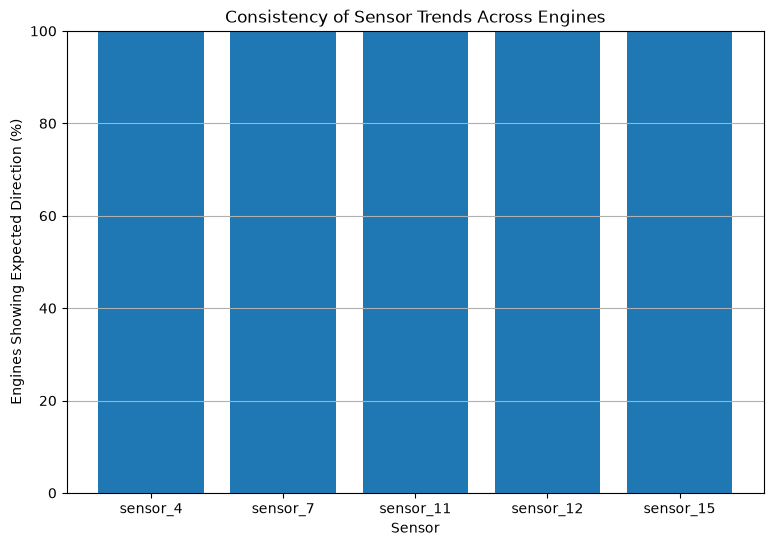

In [12]:
plt.figure(figsize=(9,6))

plt.bar(validation_table["Sensor"],validation_table["Percent Engines With Expected Direction"])

plt.title("Consistency of Sensor Trends Across Engines")

plt.xlabel("Sensor")

plt.ylabel("Engines Showing Expected Direction (%)")

plt.ylim(0,100)

plt.grid(axis="y")

plt.show()

##  Evaluation

The within-engine analysis strongly supported the findings from the previous all-sensor analysis. Sensors 4, 7, 11, 12, and 15 all demonstrated consistent relationships with normalized engine life across the entire fleet of 100 engines.

Sensor 11 demonstrated the strongest mean within-engine correlation at 0.811, followed by Sensor 12 at -0.790, Sensor 4 at 0.782, Sensor 7 at -0.762, and Sensor 15 at 0.725. Importantly, all five sensors demonstrated the expected correlation direction in 100% of the engines analyzed.

The results indicate that both increasing and decreasing sensor trends can provide useful information about engine aging. Sensors 11, 4, and 15 increase as normalized engine life progresses, while Sensors 7 and 12 decrease.

The consistency of these relationships across all 100 engines provides substantially stronger evidence than the overall correlations calculated during Day 6. However, correlation with engine life does not by itself establish that these sensors directly measure degradation or can predict failure. Further analysis is required to examine how these sensors behave specifically during the final stages of engine life and whether their changes can be used to identify approaching failure.